### Importing Libraries

In [1]:
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Warning Configuration

In [2]:
# Suppressing Runtime Warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

### Pandas Custom Configuration

In [3]:
# This snippet allow us to view all the columns without being truncated
pd.set_option('display.max_columns', None)

### Custom Seaborn Plot Style

In [4]:
# This snippet allow us to create a custom style of plots in Seaborn
sns.set_style('ticks')
sns.set_theme('paper')

### Reading CSV File

In [5]:
from churnlabs.data.loaders import load_raw_data
churn_data = load_raw_data()
churn_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Copy of Original DataFrame

In [6]:
# Making a copy of Original DataFrame
df = churn_data.copy()

### Duplicate Records

In [7]:
# Checking for Duplicated Data
print(f"Number of Duplicate records found: {df.duplicated().sum()}")

Number of Duplicate records found: 0


### Info of the DataFrame

In [8]:
# Info of the DataFrame
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
# Memory Usage of the Original Dataset (in KBs)
memory_org = df.memory_usage(deep=True).sum()/1024
print(f"Memory Usage of Original Dataset is: {memory_org:.2f}KB")

Memory Usage of Original Dataset is: 7975.08KB


### Data Cleaning

In [10]:
# Transform the Column Names by stripping whitespaces and converting to lower case
df.columns = df.columns.str.lower()

In [11]:
# Dropping Unnecessary Columns
df.drop(columns=['customerid'], inplace=True)

In [12]:
# Converting 'totalcharges' into Numerical DataType
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

In [13]:
# Dropping Null Values from 'totalcharges' Column
null_val = df['totalcharges'].isna().sum()
print(f"Null values in 'totalcharges' Column: {null_val}")
df.dropna(subset=['totalcharges'], inplace=True)

Null values in 'totalcharges' Column: 11


### Data Visualization

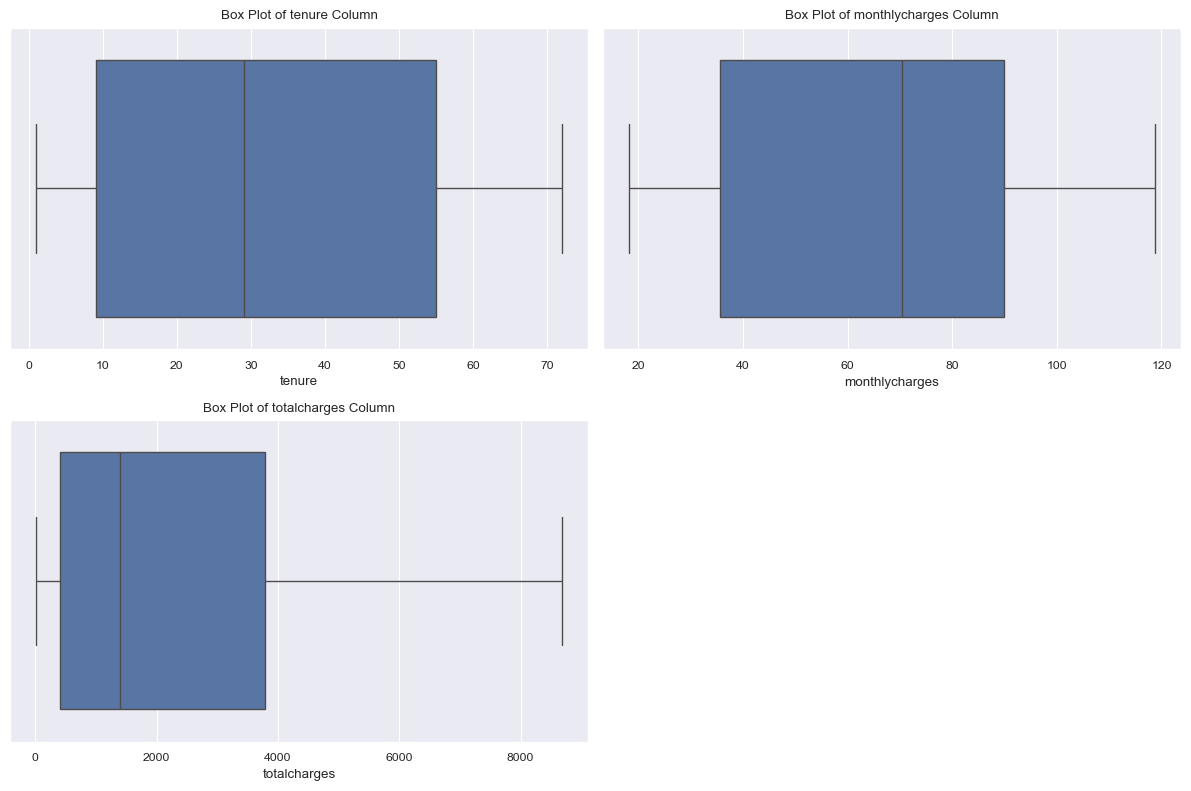

In [14]:
# Box Plot of all Numerical Columns (Continious Numerical Columns)
all_num_cols = df.select_dtypes(include='number')

num_cols = [col for col in all_num_cols if not set(df[col].dropna().unique()).issubset({0,1})]

n = len(num_cols)

cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(12,8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f"Box Plot of {col} Column")

for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

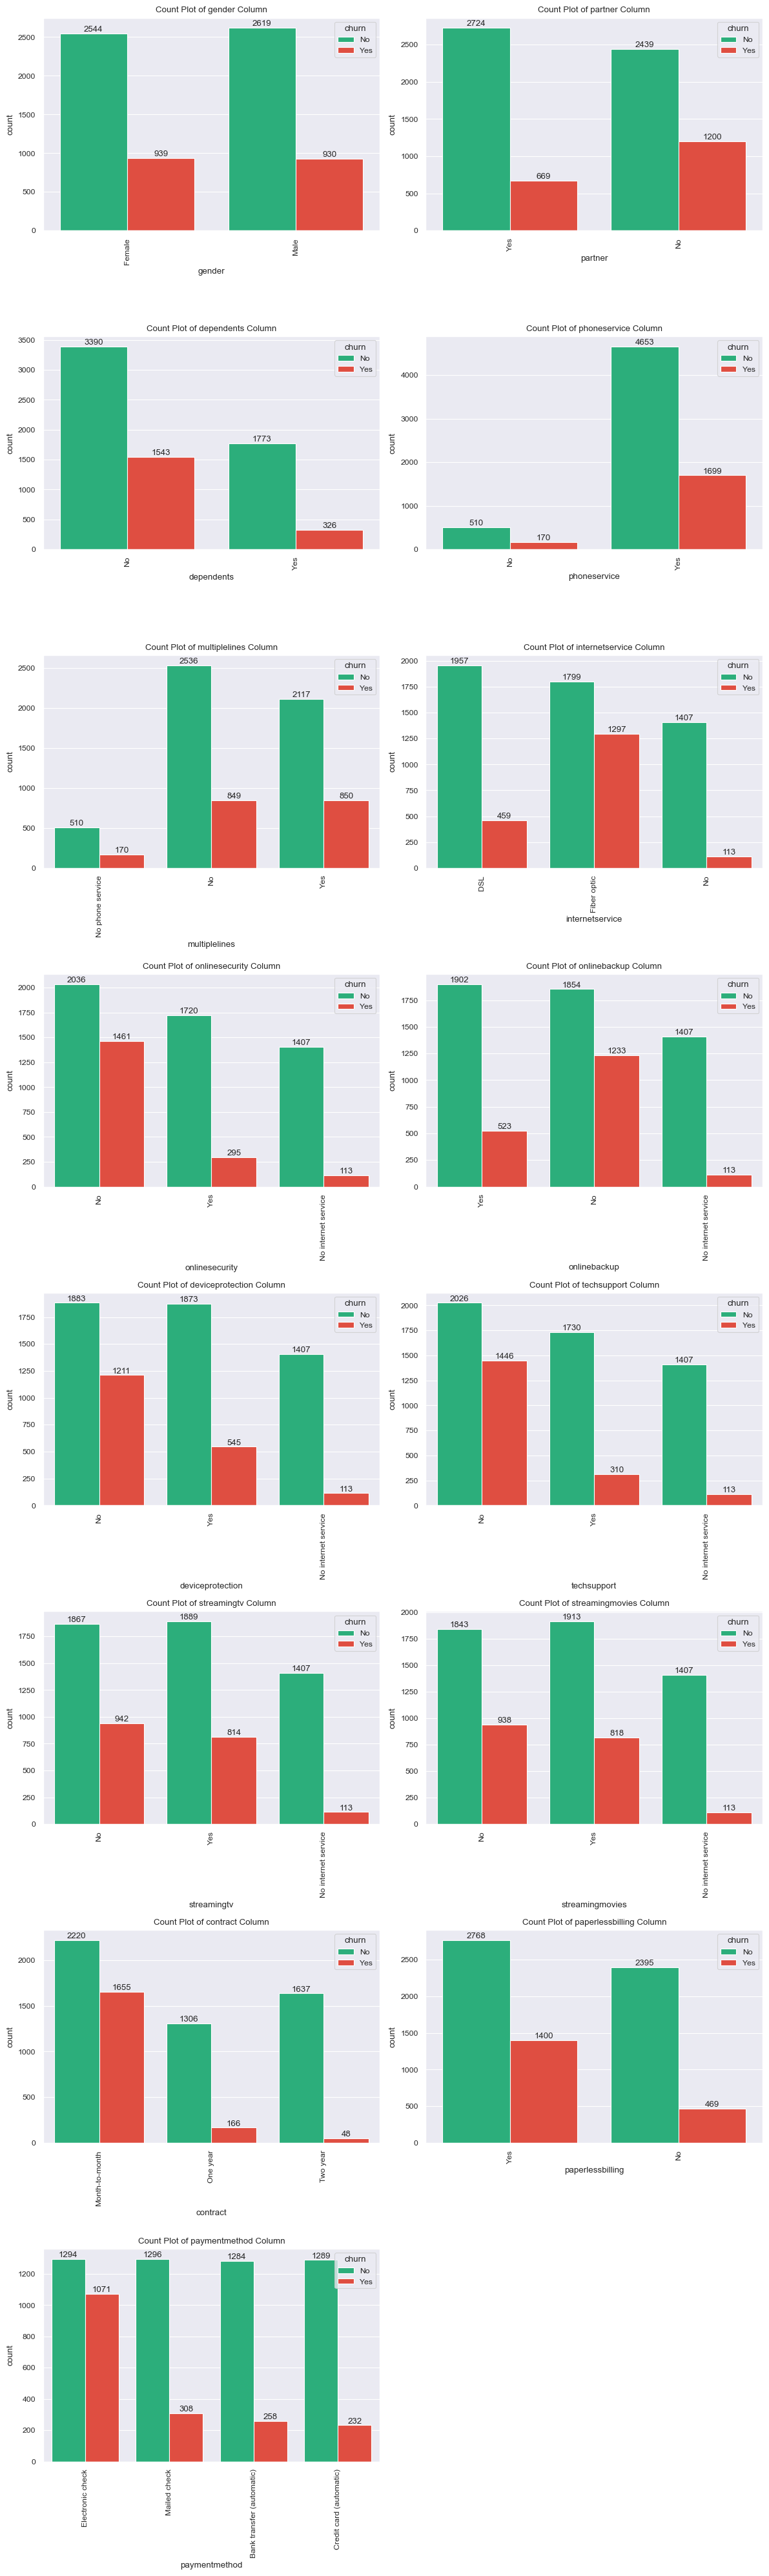

In [15]:
# Count Plot of all Categorial Columns (With hue parameter as churn Class)
cat_cols = [col for col in df.select_dtypes(include='object').columns if col != 'churn']

n = len(cat_cols)

cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(6 * cols, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    sns.countplot(data=df, x=col, ax=axes[i], hue='churn', dodge=True, palette=['#16C47F', '#F93827'])
    ax.set_title(f"Count Plot of {col} Column")
    ax.tick_params(axis='x', rotation=90)

    for container in ax.containers:
        ax.bar_label(container, label_type='edge')

for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()